# Ocean boundaries

**What this shows:** how to force SCHISM's open boundary with water levels from an
ocean model, on their own or added to the tide.

**Prerequisites:** [Tutorial 3: Tides and open boundaries](../tutorial/03_tides_and_open_boundaries.ipynb).

**You will learn:**

- how `SCHISMDataBoundary` interpolates an ocean model to the open boundary nodes
- what `elev2D.th.nc` contains
- the difference between boundary types 4 (ocean model) and 5 (tide plus ocean
  model)
- what to watch for when combining the two

**Data used:** `hgrid.gr3`, `tides/` and `glorys-perth-20230101-05.nc`, the
GLORYS12 ocean reanalysis. The runs need Docker and are skipped without it.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.source import SourceFile
from rompy.core.time import TimeRange
from rompy.core.types import DatasetCoords
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundary,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "ocean_boundaries"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
ASPECT = 1 / np.cos(np.radians(32))

grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)
hgrid = grid.pylibs_hgrid

## 1. The ocean model

GLORYS12 is a global ocean reanalysis at 1/12° (about 9 km), with daily mean sea
level, currents, temperature and salinity. Its sea level (`zos`) has no tide: it
holds the slower changes, from the Leeuwin Current, weather and the seasons, around a
mean level of its own.

[Text(0.5, 1.0, 'GLORYS sea level, 2 January'), None]

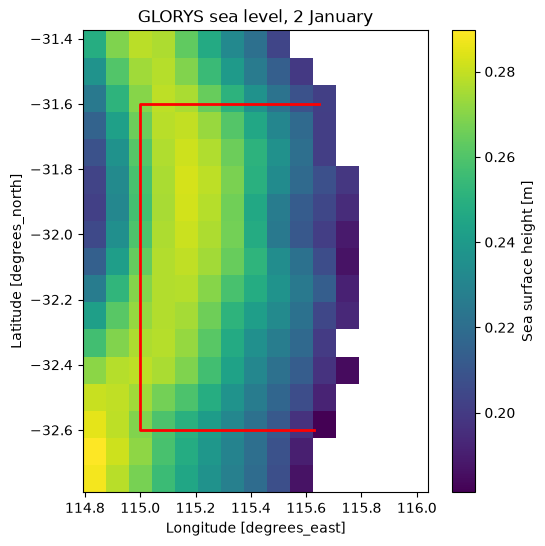

In [2]:
glorys = xr.open_dataset(DATA_DIR / "glorys-perth-20230101-05.nc")
fig, ax = plt.subplots(figsize=(6, 6))
glorys.zos.sel(time="2023-01-02").plot(ax=ax, cmap="viridis")
ax.plot(hgrid.x[hgrid.iobn[0]], hgrid.y[hgrid.iobn[0]], "r", linewidth=2)
ax.set(title="GLORYS sea level, 2 January", aspect=ASPECT)

## 2. From the ocean model to the boundary

`SCHISMDataBoundary` reads a dataset and interpolates the chosen variables to the open
boundary nodes. rompy-schism writes the result as `elev2D.th.nc` for water levels,
`uv3D.th.nc` for currents, and `TEM_3D.th.nc` and `SAL_3D.th.nc` for temperature and
salinity ([Baroclinic 3D model](baroclinic_3d.ipynb)). The coordinates tell it which
dimensions are time, longitude and latitude.

In [3]:
sea_level = SCHISMDataBoundary(
    source=SourceFile(uri=DATA_DIR / "glorys-perth-20230101-05.nc"),
    variables=["zos"],
    coords=DatasetCoords(t="time", x="longitude", y="latitude"),
)

The boundary type says how SCHISM uses it:

- **`elev_type=4`**: the water level at the boundary comes from `elev2D.th.nc` only.
  Use it when the ocean model resolves the tide, or when there is no tide.
- **`elev_type=5`**: the tidal constituents plus `elev2D.th.nc`. Use it with an ocean
  model without tides, such as GLORYS.

Two models for 1 to 4 January: the tide alone, and the tide plus GLORYS.

In [4]:
tides = TidalDataset(
    tidal_database=DATA_DIR / "tides",
    tidal_model="TPXO9-perth",
    constituents=["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"],
    nodal_corrections=True,
)
setups = {
    "tide": BoundarySetupWithSource(elev_type=3, vel_type=3),
    "tide_and_ocean": BoundarySetupWithSource(
        elev_type=5, vel_type=3, elev_source=sea_level
    ),
}
nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 15, "ihfskip": 720},
        schout={"iof_hydro__1": 1, "iof_hydro__26": 0},
    )
)
period = TimeRange(start="2023-01-01T00:00", end="2023-01-04T00:00", interval="1h")
runs = {}
for name, setup in setups.items():
    conditions = SCHISMDataBoundaryConditions(tidal_data=tides, default_boundary=setup)
    config = SCHISMConfig(
        grid=grid, data=SCHISMData(boundary_conditions=conditions), nml=nml
    )
    runs[name] = ModelRun(run_id=name, period=period, output_dir=OUT_DIR, config=config)
workspaces = {name: Path(run()) for name, run in runs.items()}

`elev2D.th.nc` has one value per open boundary node and time, at the ocean model's
daily interval. SCHISM reads only the interval (`time_step`, in seconds) and takes
the first record to be at the start of the run; it interpolates in time.

<xarray.Dataset> Size: 5kB
Dimensions:        (one: 1, time: 5, nOpenBndNodes: 115, nLevels: 1,
                    nComponents: 1)
Coordinates:
  * one            (one) int32 4B 1
  * time           (time) float32 20B 0.0 1.0 2.0 3.0 4.0
  * nOpenBndNodes  (nOpenBndNodes) int32 460B 0 1 2 3 4 ... 110 111 112 113 114
  * nLevels        (nLevels) int32 4B 0
  * nComponents    (nComponents) int32 4B 0
Data variables:
    time_step      (one) float64 8B ...
    time_series    (time, nOpenBndNodes, nLevels, nComponents) float64 5kB ...


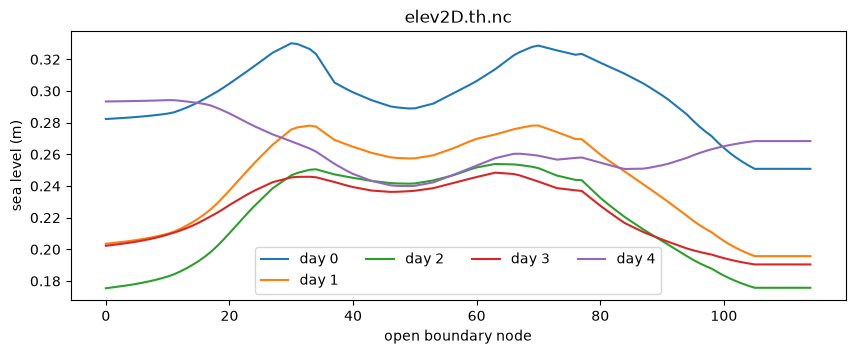

In [5]:
elev2d = xr.open_dataset(
    workspaces["tide_and_ocean"] / "elev2D.th.nc", decode_times=False
)
print(elev2d)
fig, ax = plt.subplots(figsize=(10, 3.5))
for i, values in enumerate(elev2d.time_series[:, :, 0, 0].values):
    ax.plot(values, label=f"day {elev2d.time.values[i]:.0f}")
ax.set(xlabel="open boundary node", ylabel="sea level (m)", title="elev2D.th.nc")
ax.legend(ncols=4)

## 3. Run both

In [6]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


backend = DockerConfig(image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6)
results = {}
for name, modelrun in runs.items():
    if docker_available():
        modelrun.run(backend, workspace_dir=workspaces[name])
    if run_completed(workspaces[name]):
        results[name] = xr.open_mfdataset(
            sorted((workspaces[name] / "outputs").glob("out2d_*.nc")),
            data_vars="minimal", coords="minimal", compat="override",
        )  # fmt: skip
print(f"Completed: {list(results)}")

Completed: ['tide', 'tide_and_ocean']


## 4. What the ocean model adds

At Fremantle, the ocean model raises the water level by about the GLORYS sea level
along the boundary, 0.2 to 0.3 m, and changes it slowly from day to day. Most of that
offset is GLORYS's mean level, which is relative to its own reference, not to the
datum of the mesh depths. Before combining an ocean model with tides, check that both
refer to the same datum, or remove the ocean model's mean (for example with
`mean_dynamic_topography` in [Tidal boundaries](tidal_boundaries.ipynb)).

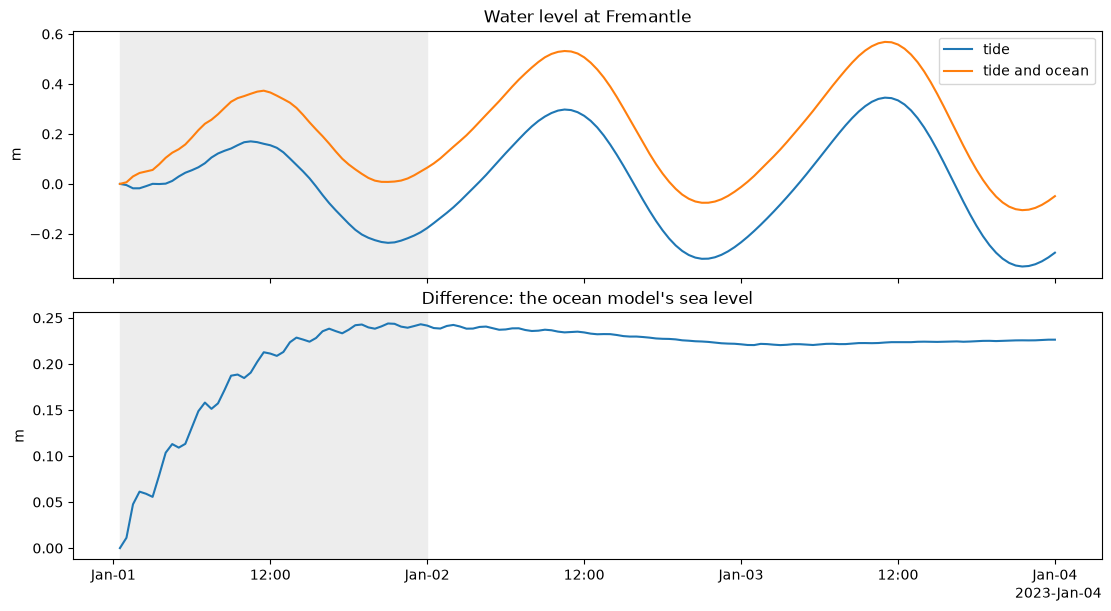

In [7]:
if len(results) == 2:
    x = results["tide"].SCHISM_hgrid_node_x.values
    y = results["tide"].SCHISM_hgrid_node_y.values
    node = np.argmin((x - 115.72) ** 2 + (y + 32.06) ** 2)
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained")
    for name, result in results.items():
        result.elevation[:, node].plot(ax=axes[0], label=name.replace("_", " "))
    difference = results["tide_and_ocean"].elevation - results["tide"].elevation
    difference[:, node].plot(ax=axes[1])
    axes[0].set(title="Water level at Fremantle", ylabel="m", xlabel="")
    axes[0].legend()
    axes[1].set(title="Difference: the ocean model's sea level", ylabel="m", xlabel="")
    start = results["tide"].time[0].values
    for ax in axes:
        ax.axvspan(start, np.datetime64("2023-01-02"), color="0.93")

## Summary

- `SCHISMDataBoundary` interpolates a dataset to the open boundary nodes and writes
  `elev2D.th.nc` (and the other boundary files).
- `elev_type=4` uses the ocean model only; `elev_type=5` adds it to the tide.
- Check the datum: an ocean model's sea level usually includes a mean level of its
  own.
- Boundary files hold the nodes of the open boundaries that use them; boundaries
  that share a file take it from the same source.